### baseline_04_V2: This iteration will continue to test new features
- Reaching the end of hard features that contain meaningful cartridge-specific variations
- This model will integrate overall length of constructed cartridge (COAL) into its list of features to see if the model continues to improve its mean absolute error without compromising the integrity of the predictions.
- Testing same set as original baseline_04 however using OLS format

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("308_baseline_data.csv")
df.head()

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,barrel_length,data_source,primer,twist_rate,coal
0,308_win,0.308,lapua,als,57.0,vihtavuori_n110,64,27.5,3481,24.0,vihtavuori,large_rifle_generic,12.0,2.638
1,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n120,81,33.6,2890,24.0,vihtavuori,large_rifle_generic,12.0,2.638
2,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n130,84,37.8,2986,24.0,vihtavuori,large_rifle_generic,12.0,2.638
3,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n133,89,41.7,3097,24.0,vihtavuori,large_rifle_generic,12.0,2.638
4,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n135,102,43.2,3123,24.0,vihtavuori,large_rifle_generic,12.0,2.638


In [5]:
features = ["charge_weight", "bullet_weight", "burn_rate_index", "coal"]
target = "velocity_fps"

X = df[features].astype(float)
y = df[target].astype(float)

# Sanity checks
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1252, 4)
y shape: (1252,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1001, 4)  Test: (251, 4)


In [8]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)

print(f"FLOOR MAE: {floor_mae:.2f}ft/s")

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
print(f"MODEL MAE (test): {model_mae:.2f}ft/s")

FLOOR MAE: 190.84ft/s
MODEL MAE (test): 51.21ft/s


Intercept: 2288.764749730464


charge_weight      45.556550
burn_rate_index    -6.682587
bullet_weight      -5.244917
coal               -4.518496
dtype: float64

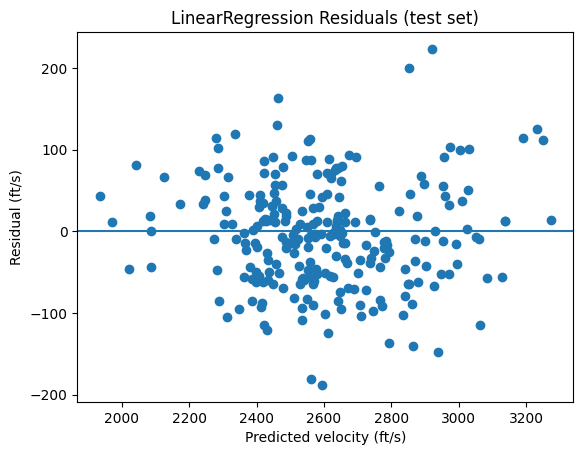

In [9]:
coefs = pd.Series(model.coef_.ravel(), index=features).sort_values(key=np.abs, ascending=False)
intercept = model.intercept_

print("Intercept:", intercept)
display(coefs)

residuals = y_test.to_numpy() - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("LinearRegression Residuals (test set)")
plt.show()

### Interpretation of results (same as original baseline_04)
- The model is showing that the added feature has some weight to it, but it is getting lost in the noise and having no contribution to the accuracy of the predictions. I will freeze using simple LinearRegression models at this point and switch to Ridge.
- Discovery from this model: A feature can be physically real and statistically detectable *yet be useless fore prediction of a given dataset.*